In [2]:
import tensorflow as tf
from tensorflow.keras import models,layers
import matplotlib.pyplot as plt
from IPython.display import HTML
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [5]:
IMAGE_SIZE = 256
CHANNELS = 3

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range = 10,
    horizontal_flip = True
    )

train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = 32,
    class_mode = 'sparse',
)

Found 1506 images belonging to 3 classes.


In [6]:
for image_batch, label_batch in train_generator:
    print(image_batch[0])
    break

[[[0.4512226  0.40024218 0.4355363 ]
  [0.447753   0.39677262 0.43206674]
  [0.44428343 0.39330304 0.42859715]
  ...
  [0.5930302  0.55040103 0.5817736 ]
  [0.57835686 0.5391412  0.5705137 ]
  [0.61776817 0.5799323  0.6108449 ]]

 [[0.40677577 0.35579538 0.3910895 ]
  [0.41284755 0.36186713 0.39716128]
  [0.4189193  0.3679389  0.40323302]
  ...
  [0.59042805 0.54823256 0.5796051 ]
  [0.58356124 0.54434556 0.5757181 ]
  [0.6160334  0.5794986  0.6099775 ]]

 [[0.39658648 0.3456061  0.3809002 ]
  [0.3970202  0.3460398  0.38133392]
  [0.3974539  0.34647352 0.38176763]
  ...
  [0.58782583 0.546064   0.57743657]
  [0.58876556 0.5495499  0.5809224 ]
  [0.6142986  0.57906485 0.60911006]]

 ...

 [[0.46533936 0.43396682 0.49279034]
  [0.45124555 0.41987297 0.47869653]
  [0.44822955 0.416857   0.47568053]
  ...
  [0.58726937 0.5598184  0.6225635 ]
  [0.5851009  0.5576499  0.620395  ]
  [0.5829324  0.55548143 0.6182265 ]]

 [[0.46577308 0.43440053 0.49322405]
  [0.44864336 0.4172708  0.47609437]


In [7]:
train_generator.class_indices

{'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2}

In [8]:
class_names = list(train_generator.class_indices.keys())
print(class_names)

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']


In [15]:
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_directory(
    'dataset/val',
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = 32,
    class_mode = 'sparse',
)

test_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range = 10,
    horizontal_flip = True
    )

test_generator = test_datagen.flow_from_directory(
    'dataset/test',
    target_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = 32,
    class_mode = 'sparse',
)

Found 215 images belonging to 3 classes.
Found 431 images belonging to 3 classes.


In [10]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3

model = models.Sequential([
    layers.InputLayer(input_shape=input_shape),
    layers.Conv2D(32, kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64,  kernel_size = (3,3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
])

In [11]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 60, 60, 64)        36928     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 30, 30, 64)        0

### Compiling the Model

In [12]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    train_generator,
    steps_per_epoch=47,
    batch_size=32,
    validation_data=validation_generator,
    validation_steps=6,
    verbose=1,
    epochs=20,
)

Epoch 1/20
47/47 [==============================] - 63s 1s/step - loss: 0.8977 - accuracy: 0.5102 - val_loss: 0.8440 - val_accuracy: 0.5104
Epoch 2/20
47/47 [==============================] - 42s 899ms/step - loss: 0.7532 - accuracy: 0.6147 - val_loss: 0.6654 - val_accuracy: 0.6927
Epoch 3/20
47/47 [==============================] - 51s 1s/step - loss: 0.6223 - accuracy: 0.7069 - val_loss: 0.5932 - val_accuracy: 0.7344
Epoch 4/20
47/47 [==============================] - 49s 1s/step - loss: 0.4041 - accuracy: 0.8270 - val_loss: 0.5161 - val_accuracy: 0.7448
Epoch 5/20
47/47 [==============================] - 46s 981ms/step - loss: 0.3164 - accuracy: 0.8779 - val_loss: 0.3830 - val_accuracy: 0.8333
Epoch 6/20
47/47 [==============================] - 70s 1s/step - loss: 0.2320 - accuracy: 0.9098 - val_loss: 0.2681 - val_accuracy: 0.8854
Epoch 7/20
47/47 [==============================] - 70s 1s/step - loss: 0.1811 - accuracy: 0.9362 - val_loss: 0.4027 - val_accuracy: 0.9010
Epoch 8/20
47/

In [17]:
scores = model.evaluate(test_generator)

14/14 [==============================] - 11s 816ms/step - loss: 0.1466 - accuracy: 0.9629


In [18]:
scores

[0.1466185450553894, 0.9628770351409912]

### Plotting the Accuracy and Loss Curves

In [19]:
history.params

{'verbose': 1, 'epochs': 20, 'steps': 47}

In [20]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

In [21]:
history.history['loss'][:5] # show loss for first 5 epochs

[0.8977109789848328,
 0.753190279006958,
 0.6222946047782898,
 0.40413111448287964,
 0.31635579466819763]

In [22]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [23]:
val_acc

[0.5104166865348816,
 0.6927083134651184,
 0.734375,
 0.7447916865348816,
 0.8333333134651184,
 0.8854166865348816,
 0.9010416865348816,
 0.9322916865348816,
 0.8697916865348816,
 0.9479166865348816,
 0.8958333134651184,
 0.9635416865348816,
 0.9322916865348816,
 0.953125,
 0.8333333134651184,
 0.9427083134651184,
 0.8854166865348816,
 0.9635416865348816,
 0.9739583134651184,
 0.9010416865348816]

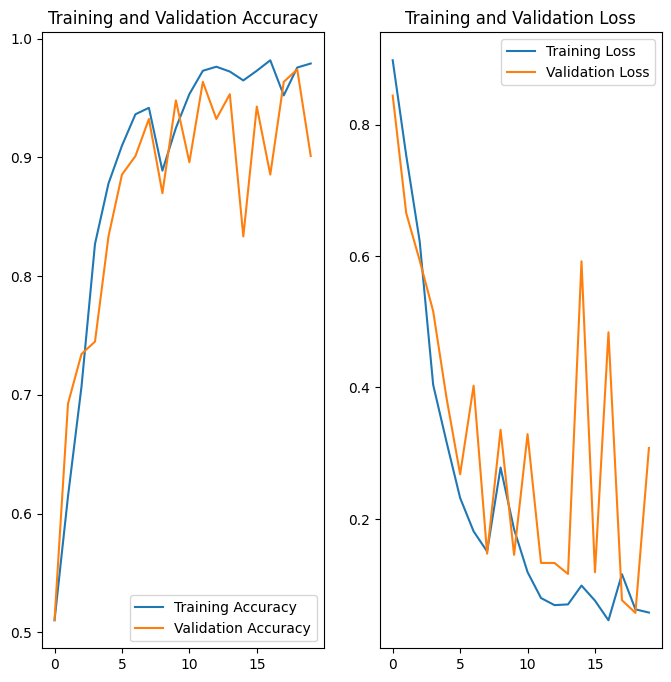

In [24]:
EPOCHS = 20

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label='Training Loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

first image to predict
actual label: Potato___Early_blight
1/1 [==============================] - 1s 733ms/step
predicted label: Potato___Early_blight


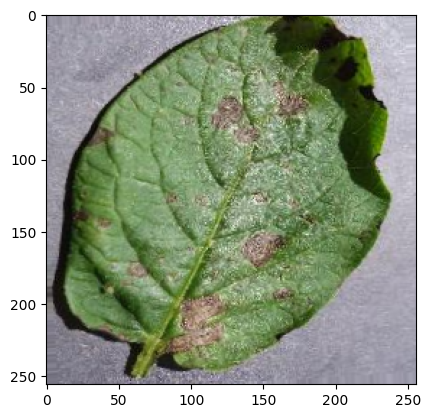

In [28]:
import numpy as np


for image_batch, label_batch in test_generator:
    first_image = image_batch[0]
    first_label = int(label_batch[0])
    
    print("first image to predict")
    plt.imshow(first_image)
    print("actual label:",class_names[first_label])
    
    batch_prediction = model.predict(image_batch)
    print("predicted label:",class_names[np.argmax(batch_prediction[0])])
    
    break

### Write a function for inference

In [29]:
def predict(model, img):
    img_array = tf.keras.preprocessing.image.img_to_array(images[i])
    img_array = tf.expand_dims(img_array, 0)

    predictions = model.predict(img_array)

    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

### Saving the Model

In [30]:
model.save("../potatoes.h5")

c:\Users\ASUS\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
